## Step 1 — Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
import random

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, KFold, LeavePOut, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

print("Libraries imported successfully.")

Libraries imported successfully.


## Step 2 — Create a Synthetic Dataset (n = 50)

We generate a binary-classification dataset with `make_classification`. Each sample
$x_i \in \mathbb{R}^d$ has a corresponding label $y_i \in \{0,1\}$, where the classes are
linearly separable to a controllable degree (`class_sep`) with some informative and
redundant features.

$$
\mathcal{D} = \{(x_i, y_i)\}_{i=1}^{n}, \qquad n = 50,\quad x_i \in \mathbb{R}^{d},\quad y_i \in \{0, 1\}
$$

In [ ]:
X, y = make_classification(
    n_samples=50,
    n_features=6,
    n_informative=4,
    n_redundant=1,
    n_repeated=0,
    n_classes=2,
    n_clusters_per_class=2,
    class_sep=1.2,
    random_state=RANDOM_STATE
)

feature_names = [f"feature_{i+1}" for i in range(X.shape[1])]
df = pd.DataFrame(X, columns=feature_names)
df["target"] = y

print(f"Dataset shape: {df.shape}")
print(f"Class balance:\n{df['target'].value_counts()}")
df.head()

Dataset shape: (50, 7)
Class balance:
target
0    25
1    25
Name: count, dtype: int64


,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,target
0,-0.501437,3.307939,-1.144949,-5.138065,-2.410016,3.137555,0
1,-1.677969,-1.696494,-0.280655,1.572985,-1.934996,-0.730976,1
2,-2.159286,-0.990456,-0.263406,-0.113784,-2.826568,0.704952,1
3,-3.740989,-1.387857,0.086566,3.008218,-0.983936,-0.519072,0
4,1.794023,0.157813,1.570111,-0.152587,1.313819,-0.497961,1


## Step 3 — Random 80:20 Train/Test Split

We randomly partition $\mathcal{D}$ into a training set and a test set:

$$
|\mathcal{D}_{train}| = 0.8 \times n = 40, \qquad |\mathcal{D}_{test}| = 0.2 \times n = 10
$$

`stratify=y` keeps the class proportions consistent between the two splits.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Train set: {X_train.shape[0]} samples")
print(f"Test set : {X_test.shape[0]} samples")

Train set: 40 samples
Test set : 10 samples


## Step 4 — Feature Scaling

SVM (and gradient-based methods in general) perform better when features are standardized:

$$
x'_{ij} = \frac{x_{ij} - \mu_j}{\sigma_j}
$$

where $\mu_j$ and $\sigma_j$ are the mean and standard deviation of feature $j$,
computed **only on the training set** to avoid data leakage.

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features standardized (mean=0, std=1 on training data).")

Features standardized (mean=0, std=1 on training data).


## Step 5 — Support Vector Machine (SVM)

SVM finds the hyperplane $w^T\phi(x) + b = 0$ that maximizes the margin between classes,
solving the soft-margin primal problem:

$$
\min_{w,\,b,\,\xi}\ \frac{1}{2}\|w\|^2 + C\sum_{i=1}^{n}\xi_i
\qquad \text{s.t. } y_i\big(w^T\phi(x_i)+b\big) \ge 1-\xi_i,\ \ \xi_i \ge 0
$$

With the RBF kernel:

$$
K(x_i, x_j) = \exp\big(-\gamma \|x_i - x_j\|^2\big)
$$

Prediction: $\hat{y} = \text{sign}\big(w^T\phi(x) + b\big)$.

In [ ]:
svm_model = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE)
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)

print("SVM trained.")
print("Predictions:", y_pred_svm)

SVM trained.
Predictions: [0 0 0 0 0 1 1 1 0 1]


## Step 6 — XGBoost

XGBoost builds an additive ensemble of trees $\hat{y}_i = \sum_{k=1}^{K} f_k(x_i)$, fitted
stage-wise by minimizing a regularized objective:

$$
\mathcal{L}^{(t)} = \sum_{i=1}^{n} l\big(y_i,\ \hat{y}_i^{(t-1)} + f_t(x_i)\big) + \Omega(f_t)
$$

$$
\Omega(f) = \gamma T + \frac{1}{2}\lambda \sum_{j=1}^{T} w_j^2
$$

where $T$ is the number of leaves, $w_j$ the leaf weights, and $\gamma,\lambda$ regularize tree complexity.

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    eval_metric="logloss",
    random_state=RANDOM_STATE
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost trained.")
print("Predictions:", y_pred_xgb)

XGBoost trained.
Predictions: [1 0 0 0 1 1 1 1 0 1]


## Step 7 — Gradient Boosting Classifier

Gradient Boosting fits each new tree $h_m$ to the negative gradient (pseudo-residuals) of the
loss with respect to the current model, then takes a shrunk step:

$$
r_{im} = -\left[\frac{\partial L(y_i, F(x_i))}{\partial F(x_i)}\right]_{F = F_{m-1}}
$$

$$
F_m(x) = F_{m-1}(x) + \nu \cdot h_m(x), \qquad 0 < \nu \le 1 \ \text{(learning rate)}
$$

In [ ]:
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=RANDOM_STATE
)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

print("Gradient Boosting trained.")
print("Predictions:", y_pred_gb)

Gradient Boosting trained.
Predictions: [0 1 0 0 0 1 1 1 0 1]


## Step 8 — Evaluation Metrics

For a binary confusion matrix (TP, TN, FP, FN):
$$ \text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN} $$

$$ \text{Precision} = \frac{TP}{TP + FP} $$


$$ \text{Recall} = \frac{TP}{TP + FN} $$


$$ F_1 Score = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}} $$

In [ ]:
def evaluate(name, y_true, y_pred):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0),
    }

results = [
    evaluate("SVM", y_test, y_pred_svm),
    evaluate("XGBoost", y_test, y_pred_xgb),
    evaluate("Gradient Boosting", y_test, y_pred_gb),
]

metrics_df = pd.DataFrame(results).set_index("Model").round(3)
metrics_df

,Accuracy,Precision,Recall,F1-score
Model,,,,
SVM,0.9,1.000,0.8,0.889
XGBoost,0.9,0.833,1.0,0.909
Gradient Boosting,0.8,0.800,0.8,0.800


## Step 9 — K-Fold Cross-Validation (variable *k*)

The data is split into $k$ equal folds. Each fold serves once as the validation set while the
remaining $k-1$ folds form the training set; the result is averaged:

$$
CV_{(k)} = \frac{1}{k}\sum_{i=1}^{k} \text{Accuracy}(M_i)
$$

We repeat this for several values of $k$ (e.g. $k = 3, 5, 10$) to see how the estimate
stabilizes as $k$ grows.

In [ ]:
k_values = [3]
models = {
    "SVM": SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1,
                              eval_metric="logloss", random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, max_depth=3,
                                                      learning_rate=0.1, random_state=RANDOM_STATE),
}

X_scaled_full = StandardScaler().fit_transform(X)  # used for SVM consistency across folds

kfold_results = []
for k in k_values:
    kf = KFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)
    for name, model in models.items():
        data_for_model = X_scaled_full if name == "SVM" else X
        scores = cross_val_score(model, data_for_model, y, cv=kf, scoring="accuracy")
        kfold_results.append({
            "k": k,
            "Model": name,
            "Mean Accuracy": scores.mean(),
            "Std Dev": scores.std(),
        })

kfold_df = pd.DataFrame(kfold_results).round(3)
kfold_pivot = kfold_df.pivot(index="Model", columns="k", values="Mean Accuracy")
kfold_pivot

k,3
Model,
Gradient Boosting,0.759
SVM,0.779
XGBoost,0.661


## Step 10 — Leave-P-Out Cross-Validation (LpO CV, variable *p*)

Leave-P-Out CV holds out **every possible subset of $p$ samples** as the test set and trains
on the remaining $n-p$ samples. The number of train/test splits is:

$$
\binom{n}{p} = \frac{n!}{p!\,(n-p)!}
$$

When $p = 1$, this reduces to the well-known **Leave-One-Out CV (LOOCV)**:

$$
CV_{(LOO)} = \frac{1}{n}\sum_{i=1}^{n} \text{Accuracy}(M_{-i})
$$

> **Note on computational cost:** for $n=50$, $p=1$ gives $\binom{50}{1}=50$ splits (fully
> exhaustive), while $p=2$ gives $\binom{50}{2}=1225$ splits. To keep runtime reasonable while
> still demonstrating larger $p$, we evaluate $p=1$ exhaustively and **randomly sample** a fixed
> number of combinations for $p \ge 2$ (a standard practice — "Monte-Carlo Leave-P-Out").

In [ ]:
p_values = [1]
MAX_SPLITS_PER_P = 100   # cap for p >= 2 to keep runtime reasonable

lpo_results = []
n_samples = X.shape[0]

for p in p_values:
    total_possible = len(list(combinations(range(0, 1), 1))) if False else None
    # build list of test-index combinations (exhaustive for p=1, sampled otherwise)
    all_combos = list(combinations(range(n_samples), p))
    if len(all_combos) > MAX_SPLITS_PER_P:
        combos = random.sample(all_combos, MAX_SPLITS_PER_P)
        note = f"sampled {MAX_SPLITS_PER_P} of {len(all_combos)} possible splits"
    else:
        combos = all_combos
        note = f"exhaustive, {len(all_combos)} splits"

    for name, model in models.items():
        data_for_model = X_scaled_full if name == "SVM" else X
        correct, total = 0, 0
        for test_idx in combos:
            test_idx = list(test_idx)
            train_idx = [i for i in range(n_samples) if i not in test_idx]

            X_tr, X_te = data_for_model[train_idx], data_for_model[test_idx]
            y_tr, y_te = y[train_idx], y[test_idx]

            m = model.__class__(**model.get_params())
            m.fit(X_tr, y_tr)
            preds = m.predict(X_te)

            correct += np.sum(preds == y_te)
            total += len(y_te)

        lpo_results.append({
            "p": p,
            "Model": name,
            "Mean Accuracy": correct / total,
            "Splits used": note,
        })

lpo_df = pd.DataFrame(lpo_results).round(3)
lpo_pivot = lpo_df.pivot(index="Model", columns="p", values="Mean Accuracy")
print(lpo_df[["p", "Splits used"]].drop_duplicates().to_string(index=False))
lpo_pivot

 p           Splits used
 1 exhaustive, 50 splits


p,1
Model,
Gradient Boosting,0.70
SVM,0.84
XGBoost,0.76


## Step 11 — Summary & Comparison

Finally, we bring the hold-out test metrics, K-Fold CV results, and Leave-P-Out CV results
together for a side-by-side comparison.

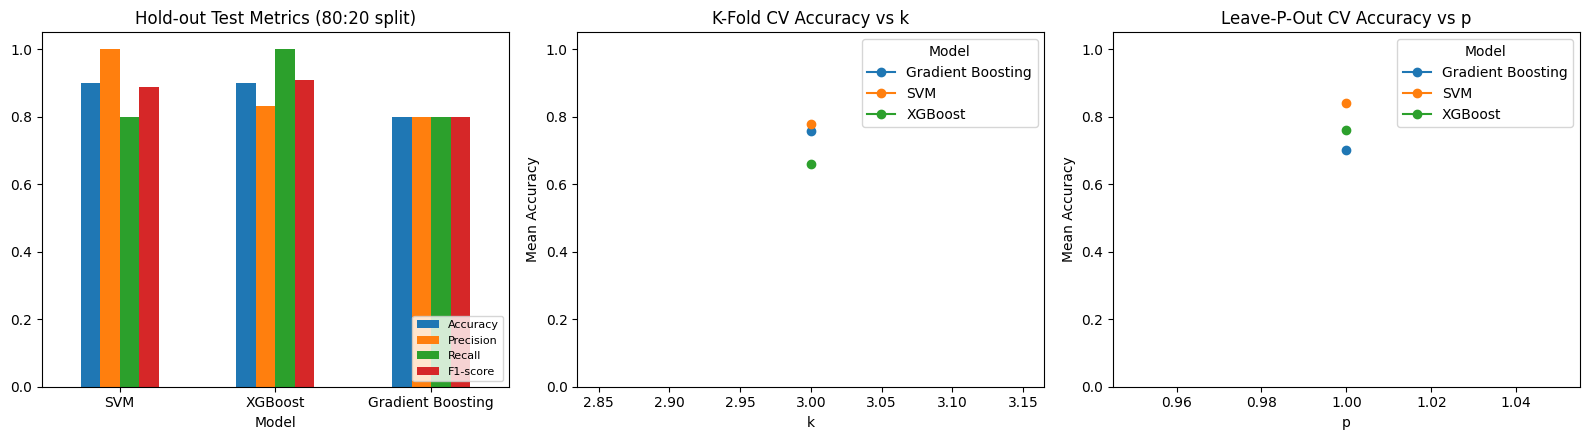

=== Hold-out Test Metrics ===
                   Accuracy  Precision  Recall  F1-score
Model                                                   
SVM                     0.9      1.000     0.8     0.889
XGBoost                 0.9      0.833     1.0     0.909
Gradient Boosting       0.8      0.800     0.8     0.800 

=== K-Fold CV (Mean Accuracy by k) ===
k                      3
Model                   
Gradient Boosting  0.759
SVM                0.779
XGBoost            0.661 

=== Leave-P-Out CV (Mean Accuracy by p) ===
p                     1
Model                  
Gradient Boosting  0.70
SVM                0.84
XGBoost            0.76


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# (a) Hold-out metrics
metrics_df[["Accuracy", "Precision", "Recall", "F1-score"]].plot(
    kind="bar", ax=axes[0], rot=0
)
axes[0].set_title("Hold-out Test Metrics (80:20 split)")
axes[0].set_ylim(0, 1.05)
axes[0].legend(loc="lower right", fontsize=8)

# (b) K-Fold CV
kfold_pivot.T.plot(marker="o", ax=axes[1])
axes[1].set_title("K-Fold CV Accuracy vs k")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Mean Accuracy")
axes[1].set_ylim(0, 1.05)

# (c) Leave-P-Out CV
lpo_pivot.T.plot(marker="o", ax=axes[2])
axes[2].set_title("Leave-P-Out CV Accuracy vs p")
axes[2].set_xlabel("p")
axes[2].set_ylabel("Mean Accuracy")
axes[2].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

print("=== Hold-out Test Metrics ===")
print(metrics_df, "\n")
print("=== K-Fold CV (Mean Accuracy by k) ===")
print(kfold_pivot, "\n")
print("=== Leave-P-Out CV (Mean Accuracy by p) ===")
print(lpo_pivot)